# 04 — Initialization Experiment (lưới 5×4 = 20 cấu hình)

Nạp lại log JSON đã chạy thật (`results/logs/run_*.json`, sinh bởi `experiments/run_initialization.py`) — không chạy lại ở đây để tiết kiệm thời gian, chỉ tổng hợp và hiển thị.

In [1]:
import sys, json, glob
sys.path.insert(0, '..')
import pandas as pd
df = pd.read_csv('results/tables/initialization_comparison.csv')
df.sort_values(['activation','scheme'])

,scheme,activation,final_train_loss,final_val_loss,final_val_acc,test_loss,test_acc,initial_grad_rms_layer1,initial_grad_rms_layer6
19,he,leaky_relu,0.258000,2.691431,0.624,2.578532,0.6340,2.792821e-02,4.581026e-02
11,lecun,leaky_relu,0.385060,1.806798,0.657,1.731703,0.6475,1.398145e-03,1.238898e-03
7,random_normal,leaky_relu,2.302697,2.303180,0.094,2.302667,0.1000,2.779132e-09,6.350159e-09
15,xavier,leaky_relu,0.372936,1.481851,0.682,1.410129,0.6815,2.022431e-03,2.395723e-03
3,zero,leaky_relu,2.302697,2.303180,0.094,2.302667,0.1000,0.000000e+00,0.000000e+00
18,he,relu,0.256375,1.919175,0.672,1.821961,0.6665,2.753936e-02,4.571339e-02
10,lecun,relu,0.389655,1.807581,0.646,1.741589,0.6380,1.396684e-03,1.237709e-03
6,random_normal,relu,2.302697,2.303180,0.094,2.302667,0.1000,2.780886e-09,6.350303e-09
14,xavier,relu,0.378224,1.423117,0.677,1.372662,0.6735,2.016898e-03,2.390657e-03
2,zero,relu,2.302697,2.303180,0.094,2.302667,0.1000,0.000000e+00,0.000000e+00


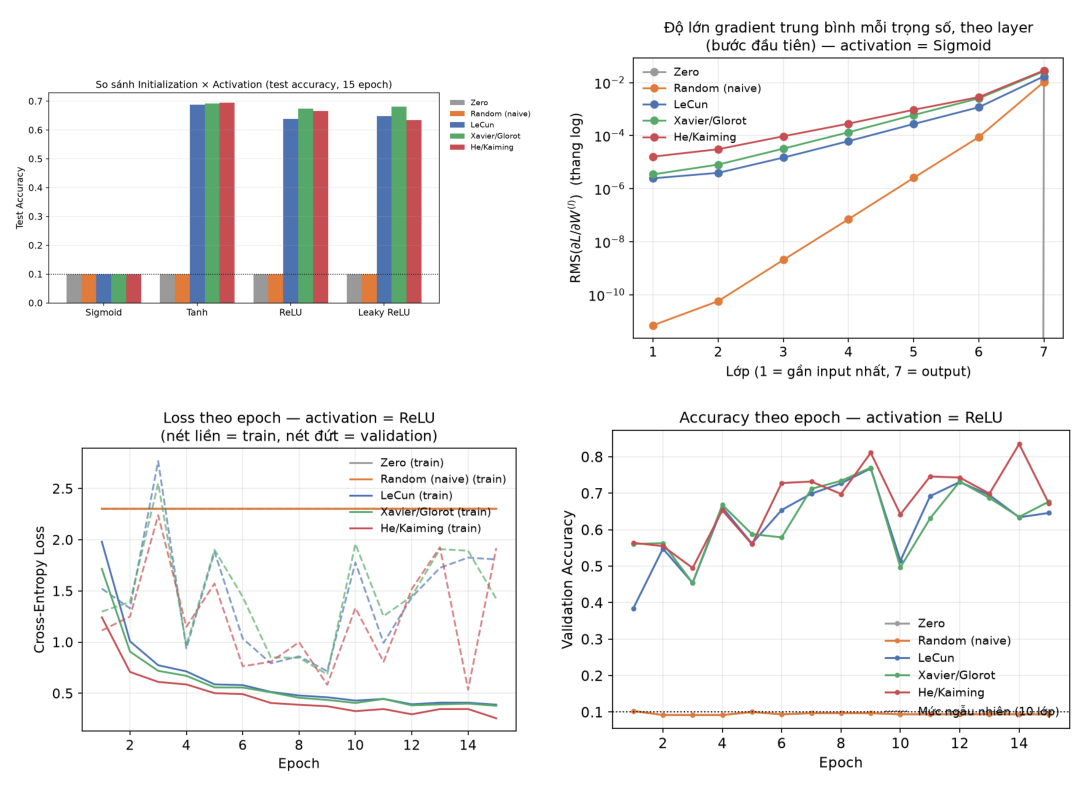

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
fig, axes = plt.subplots(2,2, figsize=(11,8))
imgs = ['initialization_comparison.png','gradient_norm.png',
        'loss_comparison.png','accuracy_comparison.png']
for ax, name in zip(axes.flat, imgs):
    ax.imshow(mpimg.imread(f'results/figures/{name}'))
    ax.axis('off')
plt.tight_layout(); plt.show()

Quan sát nhanh (phân tích đầy đủ ở `05_analysis.ipynb` và report Mục 9–10): Zero/Random (naive) đứng yên ở mức ngẫu nhiên (~10%) với MỌI activation; Sigmoid thất bại với MỌI initialization ở độ sâu 6 lớp trong 15 epoch; LeCun/Xavier/He đều học tốt với Tanh/ReLU/Leaky ReLU (~64–70% test accuracy).